# Tebas Fairplay Report (Fantasy S2)

In [1]:
import numpy as np
import pandas as pd

trading_df = pd.read_csv('../data/trading.csv')
trading_df['date'] = pd.to_datetime(trading_df['date']).dt.date
trading_df.head(10)

,date,type,team1,team2,player,amount
0,2026-03-28,purchased,Ramonaco FC,LALIGA,Huijsen,66666668
1,2026-03-28,purchased,cristian.ayala12,LALIGA,Turrientes,1330000
2,2026-03-28,purchased,cristian.ayala12,LALIGA,Ruggeri,7770000
3,2026-03-28,sold,JMjugon,LALIGA,S. Cazorla,753651
4,2026-03-28,sold,JMjugon,LALIGA,Denis Suarez,695918
5,2026-03-27,purchased,PlatanosVerdes,Millou912,Rioja,25000000
6,2026-03-27,purchased,cristian.ayala12,PlatanosVerdes,Alvaro Garcia,17000000
7,2026-03-27,sold,PavelmacuFC,LALIGA,Odriozola,760947
8,2026-03-27,purchased,tete alejo,La rataneta,Brahim,6276238
9,2026-03-27,purchased,La rataneta,tete alejo,Ratiu,57821529


In [2]:
assert not(trading_df['date'].diff().dropna().dt.days > 0).any()

## Transactions

### All transactions plot

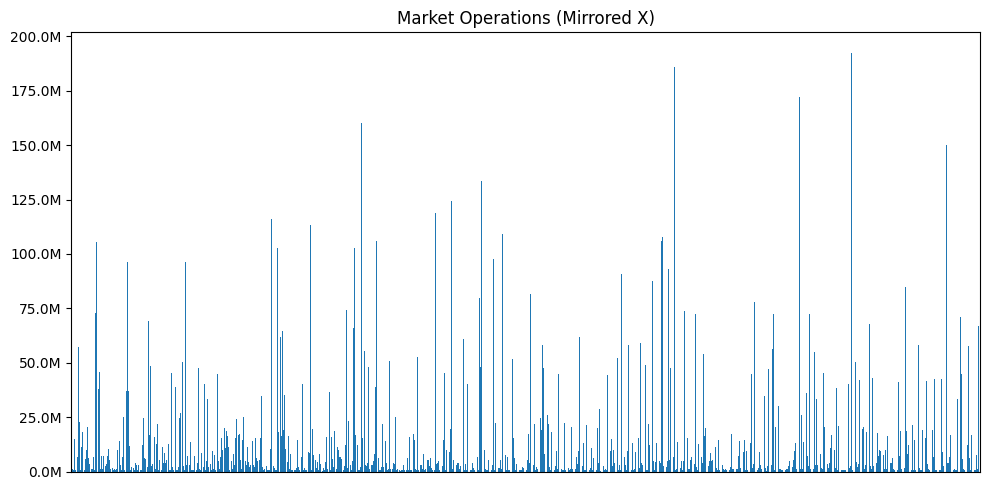

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(trading_df.index, trading_df['amount'])

# Invertir eix X
off = 1
ax.set_xlim(-off, len(trading_df) - off)
ax.invert_xaxis()

# Format milions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

plt.title('Market Operations (Mirrored X)')
plt.xticks([])

plt.tight_layout()
plt.show()

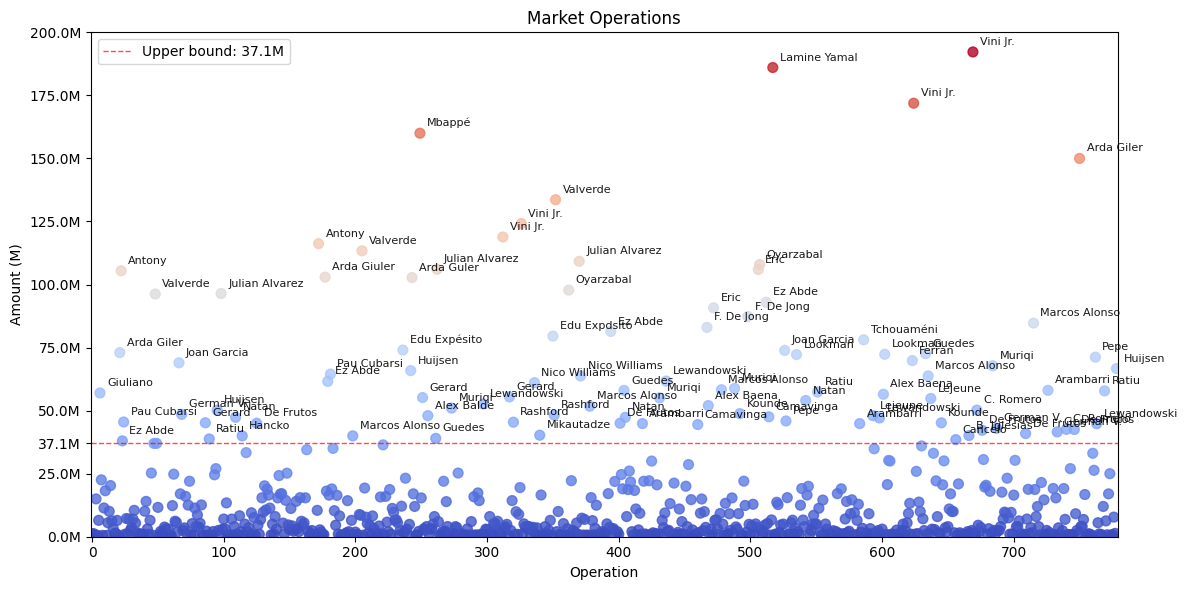

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

amounts = trading_df['amount'].values
n = len(amounts)

# Reversed positions: first record on the right, last on the left
x_plot = np.arange(n - 1, -1, -1)

# Scatter plot with color gradient: blue (cheap) -> red (expensive)
norm = plt.Normalize(vmin=amounts.min(), vmax=amounts.max())
sc = ax.scatter(x_plot, amounts, c=amounts, cmap='coolwarm', alpha=0.8, s=50, norm=norm)

# Detect outliers using IQR
Q1 = np.percentile(amounts, 25)
Q3 = np.percentile(amounts, 75)
IQR = Q3 - Q1
lower_bound = 0 #Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Draw upper bound line
ax.axhline(y=upper_bound, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Upper bound: {upper_bound/1e6:.1f}M')
ax.legend()

outliers_mask = (amounts < lower_bound) | (amounts > upper_bound)

# Label outliers with player names
players = trading_df['player'].values
for i, (is_outlier, amount, player) in enumerate(zip(outliers_mask, amounts, players)):
    if is_outlier:
        ax.annotate(
            player,
            (x_plot[i], amount),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.9
        )

# X axis: 0 on the left, max on the right
ax.set_xlim(-1, n)
ax.set_ylim(0, amounts.max())

# Format millions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Add upper_bound to Y axis ticks
current_ticks = list(ax.get_yticks())
current_ticks.append(upper_bound)
ax.set_yticks(sorted(current_ticks))

plt.title('Market Operations')
plt.xlabel('Operation')
plt.ylabel('Amount (M)')

plt.tight_layout()
plt.show()

### Top transactions

In [5]:
trading_df.sort_values('amount', ascending=False).head(15)

,date,type,team1,team2,player,amount
109,2026-03-17,sold,Ramonaco FC,LALIGA,Vini Jr.,192220472
261,2026-03-02,purchased,La rataneta,LALIGA,Lamine Yamal,186047732
154,2026-03-11,purchased,Ramonaco FC,LALIGA,Vini Jr.,171892491
529,2026-02-03,purchased,LILTEAM,LALIGA,Mbappé,160000000
28,2026-03-25,purchased,Ramonaco FC,LALIGA,Arda Giler,149999999
426,2026-02-13,sold,cristian.ayala12,LALIGA,Valverde,133631252
452,2026-02-11,sold,Millou912,LALIGA,Vini Jr.,124154664
466,2026-02-10,purchased,Millou912,LALIGA,Vini Jr.,118836312
606,2026-01-27,sold,LILTEAM,LALIGA,Antony,116209495
573,2026-01-30,purchased,cristian.ayala12,Ramonaco FC,Valverde,113368973


### Daily stats

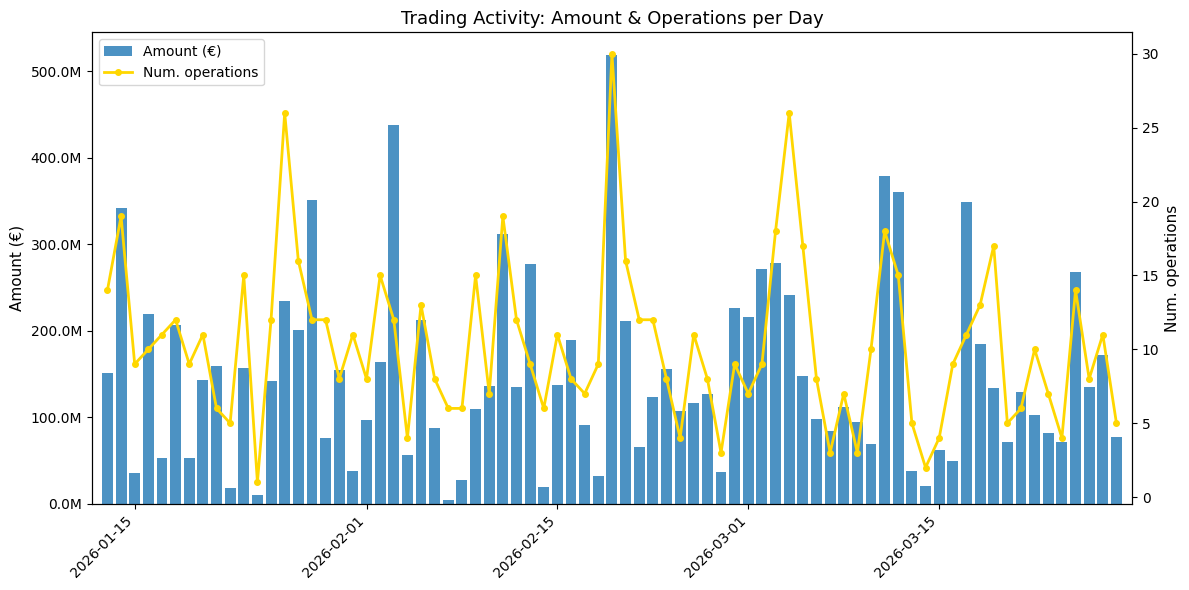

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import datetime

# --- Aggregation ---
date_groups = trading_df.groupby('date')

daily_amount = date_groups['amount'].sum()
daily_counts = trading_df['date'].value_counts()

# Full date range
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily_amount = daily_amount.reindex(full_range, fill_value=0)
daily_counts = daily_counts.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Bars (amount)
bars = ax1.bar(
    daily_amount.index,
    daily_amount,
    width=0.8,
    alpha=0.8,
    label='Amount (€)'
)

ax1.set_ylabel('Amount (€)', fontsize=11)

# Format Y axis in millions
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Line (counts)
ax2 = ax1.twinx()
ax2.plot(
    daily_counts.index,
    daily_counts,
    marker='o',
    color='gold',
    linewidth=2,
    markersize=4,
    label='Num. operations'
)

ax2.set_ylabel('Num. operations', fontsize=11)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

# --- X axis formatting (KEY PART) ---
ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

# --- Baseline ---
ax1.axhline(0, linewidth=0.6, color='black', alpha=0.6)

# --- Margins ---
ax1.margins(x=0.01)

# --- Title ---
plt.title('Trading Activity: Amount & Operations per Day', fontsize=13)

# --- Layout ---
plt.tight_layout()

plt.show()

#### Top days with more amount

In [7]:
dd = daily_amount.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    518762461
2026-02-03    437345511
2026-03-11    378578788
2026-03-12    360767106
2026-01-28    350817669
                ...    
2026-03-14     20000000
2026-02-14     19545359
2026-01-22     18393833
2026-01-24      9500000
2026-02-07      4014859
Name: amount, Length: 75, dtype: int64

,date,type,team1,team2,player,amount
355,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
356,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
357,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
358,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
359,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
360,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
361,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
362,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
363,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
364,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


#### Top days with more operations

In [8]:
dd = daily_counts.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    30
2026-01-26    26
2026-03-04    26
2026-02-11    19
2026-01-14    19
              ..
2026-03-09     3
2026-02-27     3
2026-03-07     3
2026-03-14     2
2026-01-24     1
Name: count, Length: 75, dtype: int64

,date,type,team1,team2,player,amount
355,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
356,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
357,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
358,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
359,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
360,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
361,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
362,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
363,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
364,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


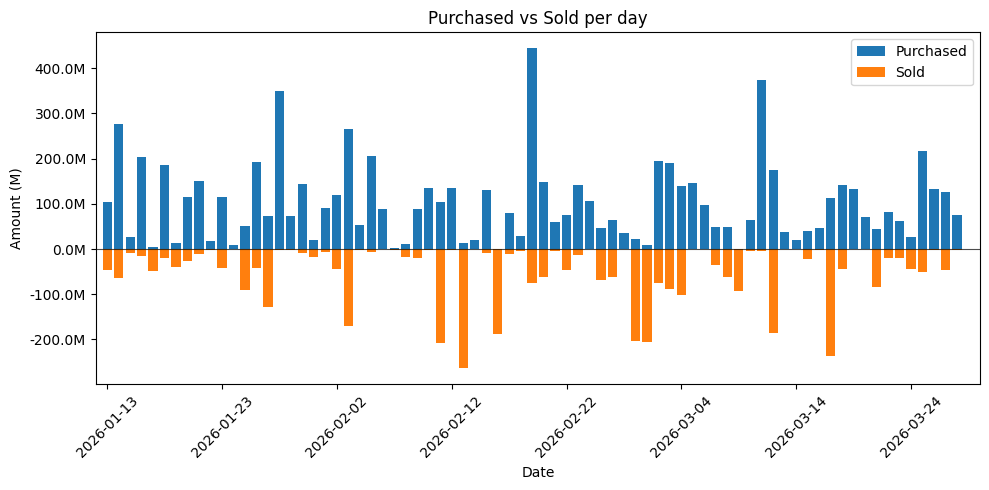

In [9]:
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily = trading_df.groupby(['date', 'type'])['amount'].sum().unstack(fill_value=0)
daily = daily.reindex(full_range, fill_value=0)
daily = daily.reindex(columns=['purchased', 'sold'], fill_value=0)

plt.figure(figsize=(10,5))

# Purchased (positive)
x = np.arange(len(daily))
plt.bar(x, daily['purchased'], label='Purchased')
plt.bar(x, -daily['sold'], label='Sold')

plt.xticks(x, daily.index.strftime('%Y-%m-%d'), rotation=45)

plt.title('Purchased vs Sold per day')
plt.xlim(-1, len(x)+1)
plt.xlabel('Date')
plt.ylabel('Amount (M)')

step= 10
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(x[::step], daily.index.strftime('%Y-%m-%d')[::step], rotation=45)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
daily['diff'] = daily['sold'] - daily['purchased']
daily

type,purchased,sold,diff
2026-01-13,104276294,46271593,-58004701
2026-01-14,277528645,63748033,-213780612
2026-01-15,26750001,8431704,-18318297
2026-01-16,203500840,15240395,-188260445
2026-01-17,4221331,48762351,44541020
...,...,...,...
2026-03-24,25987123,44997689,19010566
2026-03-25,217769728,49840274,-167929454
2026-03-26,133259680,1507975,-131751705
2026-03-27,126223880,45567418,-80656462


## Teams

## Fairplay

In [11]:
print(trading_df['player'].value_counts().head(15))

player
Alvaro Garcia    9
De Galarreta     6
Victor Mufoz     6
Cardona          6
Brahim           5
Griezmann        5
De Frutos        5
Ugrinic          5
A. Valles        5
Sorloth          5
Laporte          5
Marcos Alonso    5
Akor             5
Ounahi           5
Witsel           5
Name: count, dtype: int64


In [12]:
trading_df['fp'] = np.nan
for player, group_df in trading_df.groupby('player'):
    fp = group_df['date'].iloc[::-1].diff()
    if len(fp) > 1:
        for idx, value in fp.items():
            row = trading_df.loc[idx]
            trading_df.at[idx, 'fp'] = float(value.days)

trading_df

,date,type,team1,team2,player,amount,fp
0,2026-03-28,purchased,Ramonaco FC,LALIGA,Huijsen,66666668,53.0
1,2026-03-28,purchased,cristian.ayala12,LALIGA,Turrientes,1330000,40.0
2,2026-03-28,purchased,cristian.ayala12,LALIGA,Ruggeri,7770000,45.0
3,2026-03-28,sold,JMjugon,LALIGA,S. Cazorla,753651,18.0
4,2026-03-28,sold,JMjugon,LALIGA,Denis Suarez,695918,11.0
...,...,...,...,...,...,...,...
774,2026-01-13,purchased,La rataneta,LALIGA,Vilaplana,584831,NaN
775,2026-01-13,purchased,La Agustineta 96,LALIGA,David Soria,15000000,NaN
776,2026-01-13,purchased,La rataneta,LALIGA,Marc Bernal,710000,NaN
777,2026-01-13,purchased,Ramonaco FC,LALIGA,Kiko F.,1251000,NaN


In [13]:
trading_df[~trading_df['fp'].isnull()]

,date,type,team1,team2,player,amount,fp
0,2026-03-28,purchased,Ramonaco FC,LALIGA,Huijsen,66666668,53.0
1,2026-03-28,purchased,cristian.ayala12,LALIGA,Turrientes,1330000,40.0
2,2026-03-28,purchased,cristian.ayala12,LALIGA,Ruggeri,7770000,45.0
3,2026-03-28,sold,JMjugon,LALIGA,S. Cazorla,753651,18.0
4,2026-03-28,sold,JMjugon,LALIGA,Denis Suarez,695918,11.0
...,...,...,...,...,...,...,...
685,2026-01-20,sold,JMjugon,LALIGA,Alvaro Nufiez,24555404,4.0
694,2026-01-20,purchased,JMjugon,LALIGA,Alvaro Garcia,581988,2.0
700,2026-01-19,sold,-papi—,LALIGA,A. Batalla,11375056,1.0
701,2026-01-19,sold,-papi—,LALIGA,Stuani,589292,5.0


In [14]:
mask_purchased = (trading_df['type'] == 'purchased') & (trading_df['team2'] != 'LALIGA')
mask_sold = (trading_df['type'] == 'sold') & (trading_df['team2'] == 'LALIGA')

targets = trading_df[mask_purchased | mask_sold]
display(targets)
targets['team1'].value_counts()

,date,type,team1,team2,player,amount,fp
3,2026-03-28,sold,JMjugon,LALIGA,S. Cazorla,753651,18.0
4,2026-03-28,sold,JMjugon,LALIGA,Denis Suarez,695918,11.0
5,2026-03-27,purchased,PlatanosVerdes,Millou912,Rioja,25000000,34.0
6,2026-03-27,purchased,cristian.ayala12,PlatanosVerdes,Alvaro Garcia,17000000,14.0
7,2026-03-27,sold,PavelmacuFC,LALIGA,Odriozola,760947,71.0
...,...,...,...,...,...,...,...
766,2026-01-13,sold,LILTEAM,LALIGA,Puado,5542618,NaN
767,2026-01-13,sold,-papi—,LALIGA,D. Martinez,503413,NaN
768,2026-01-13,sold,-papi—,LALIGA,Vargas,18236496,NaN
769,2026-01-13,sold,-papi—,LALIGA,Laporte,11400818,NaN


team1
-papi—              91
Ramonaco FC         62
cristian.ayala12    48
La rataneta         46
Millou912           44
LamineTheTuareg     41
JMjugon             36
PlatanosVerdes      32
La Agustineta 96    30
LILTEAM             29
tete alejo          22
PavelmacuFC         21
Name: count, dtype: int64

In [15]:
targets[targets['fp'] == 5]

,date,type,team1,team2,player,amount,fp
32,2026-03-25,sold,cristian.ayala12,LALIGA,De Frutos,42512052,5.0
48,2026-03-23,sold,Ramonaco FC,LALIGA,Sorloth,19130504,5.0
120,2026-03-15,sold,-papi—,LALIGA,Oblak,20946467,5.0
141,2026-03-12,sold,La rataneta,LALIGA,Lejeune,54819768,5.0
178,2026-03-08,sold,-papi—,LALIGA,Bellerin,3009073,5.0
196,2026-03-05,purchased,LILTEAM,La rataneta,Kubo,12869000,5.0
226,2026-03-04,sold,tete alejo,LALIGA,Pere Milla,11298289,5.0
258,2026-03-02,sold,-papi—,LALIGA,Griezmann,13665151,5.0
280,2026-02-28,sold,Ramonaco FC,LALIGA,F. De Jong,87326198,5.0
291,2026-02-26,sold,Ramonaco FC,LALIGA,Lucas Beltran,1393392,5.0


In [16]:
player_name = 'Carlos V.'
gg = trading_df.groupby('player')
player = gg.get_group(player_name)
display(player)


,date,type,team1,team2,player,amount,fp
607,2026-01-27,sold,-papi—,LALIGA,Carlos V.,10458503,1.0
620,2026-01-26,purchased,-papi—,LILTEAM,Carlos V.,15495043,NaN
